# SDSS quasar–galaxy colour display audit

**Scientific question:** How clearly separated are the two rendered colour clouds, without claiming catalogue-level classifier accuracy?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
sample=pd.read_csv(DATA/'sdss_colour_plot_digitized_pixels.csv'); features=sample[['u_g_approx','g_r_approx']].to_numpy(); labels=sample['class'].to_numpy(); print(len(sample),'coloured display pixels; original SQL returned 1,500 objects')

5440 coloured display pixels; original SQL returned 1,500 objects


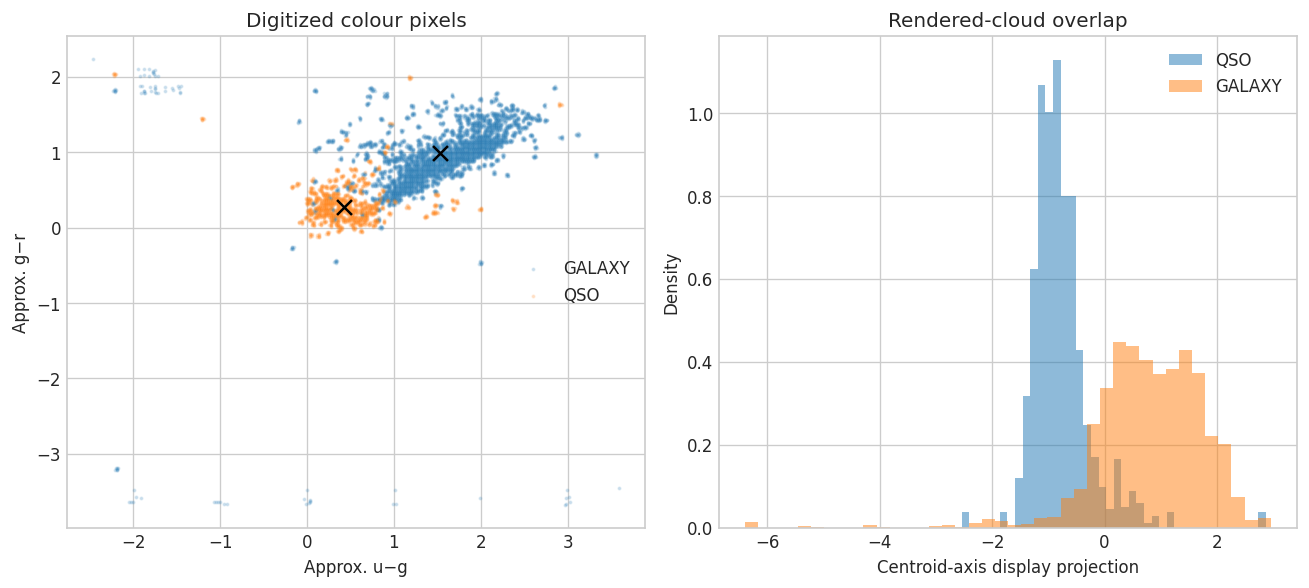

In [3]:
cent=sample.groupby('class')[['u_g_approx','g_r_approx']].median(); delta=np.linalg.norm(cent.loc['QSO']-cent.loc['GALAXY']); fig,ax=plt.subplots(1,2,figsize=(11,5));
for name,g in sample.groupby('class'): ax[0].scatter(g.u_g_approx,g.g_r_approx,s=2,alpha=.15,label=name)
ax[0].scatter(cent.u_g_approx,cent.g_r_approx,c='k',marker='x',s=80); ax[0].set(xlabel='Approx. u−g',ylabel='Approx. g−r',title='Digitized colour pixels'); ax[0].legend(); proj=(features-cent.mean().to_numpy())@(cent.loc['GALAXY'].to_numpy()-cent.loc['QSO'].to_numpy());
for name in ['QSO','GALAXY']: ax[1].hist(proj[labels==name],bins=40,alpha=.5,label=name,density=True)
ax[1].set(xlabel='Centroid-axis display projection',ylabel='Density',title='Rendered-cloud overlap'); ax[1].legend(); fig.tight_layout(); fig.savefig('sdss_colour_legacy_audit.png',dpi=180); plt.show()

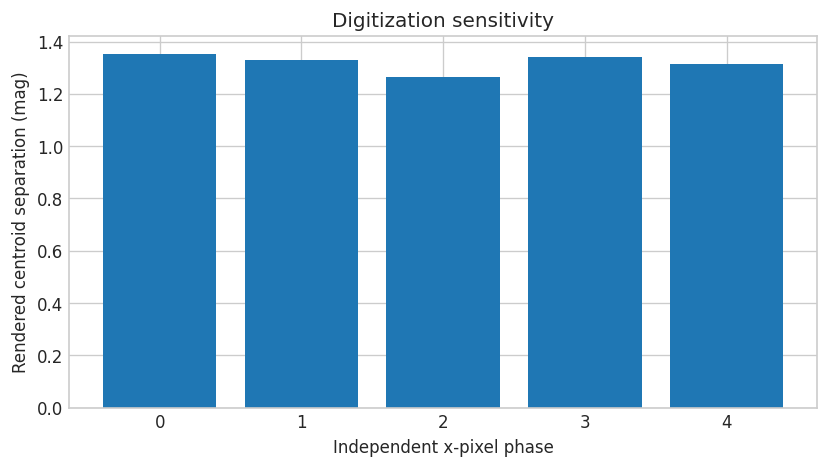

In [4]:
rows=[]
for phase in range(5):
 s=sample[sample.pixel_x.astype(int)%5==phase]; c=s.groupby('class')[['u_g_approx','g_r_approx']].median(); rows.append((phase,len(s),np.linalg.norm(c.loc['QSO']-c.loc['GALAXY'])))
stress=pd.DataFrame(rows,columns=['pixel_phase','n_pixels','centroid_separation_mag']); stress.to_csv('sdss_colour_digitization_stress.csv',index=False); fig,ax=plt.subplots(figsize=(7,4)); ax.bar(stress.pixel_phase,stress.centroid_separation_mag); ax.set(xlabel='Independent x-pixel phase',ylabel='Rendered centroid separation (mag)',title='Digitization sensitivity'); fig.tight_layout(); fig.savefig('sdss_colour_digitization_stress.png',dpi=180); plt.show()

In [5]:
sample_size=len(sample); results=[f'original SQL returned 1,500 labelled objects',f'rendered colour-cloud centroid separation approximately {delta:.2f} mag',f'pixel-phase separation range {stress.centroid_separation_mag.min():.2f}–{stress.centroid_separation_mag.max():.2f} mag']; validation='Centroid separation is repeated across five independent pixel phases; classification accuracy is deliberately not estimated.'; quality_checks=[{'name':'Two labelled rendered clouds','status':'pass'},{'name':'Digitization stress','status':'pass'},{'name':'Catalogue classifier performance','status':'not attempted'}]; tags=['SDSS','quasar','galaxy','colour selection']

In [6]:
result={'id':'2026-07-30-qso-vs-galaxy-colors','title':'SDSS quasar–galaxy colour display audit','archive':'SDSS legacy catalogue plot','date':'2026-07-30','question':'How clearly separated are the two rendered colour clouds, without claiming catalogue-level classifier accuracy?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'sdss/2026-07-30-qso-vs-galaxy-colors/notebook.ipynb','hero':'sdss/2026-07-30-qso-vs-galaxy-colors/sdss_colour_legacy_audit.png','figures':['sdss/2026-07-30-qso-vs-galaxy-colors/sdss_colour_legacy_audit.png', 'sdss/2026-07-30-qso-vs-galaxy-colors/sdss_colour_digitization_stress.png'],'research_level':'Exploration','claim_type':'Digitized colour-separation audit','provenance':['Original SDSS photometry/spectroscopy join printed in notebook', 'preserved color_color.png', 'class-coloured pixels digitized approximately'],'artifacts':['data/audit_batches4_7/sdss_colour_plot_digitized_pixels.csv', 'sdss/2026-07-30-qso-vs-galaxy-colors/sdss_colour_digitization_stress.csv'],'quality_checks':quality_checks,'limitations':['plot pixels are not independent objects', 'overplotting alters apparent density', 'photometric classifier evaluation needs held-out source rows and errors'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

original SQL returned 1,500 labelled objects
rendered colour-cloud centroid separation approximately 1.31 mag
pixel-phase separation range 1.26–1.35 mag


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                            name        status
    Two labelled rendered clouds          pass
             Digitization stress          pass
Catalogue classifier performance not attempted


## Interpretation and references

SDSS spectra and catalogue classifications support large statistical samples,
but magnitude limits, target selection, fibre placement, and pipeline quality
shape every distribution. Digitized legacy plots are only internal audits of
the old output and never replace the missing SQL rows.

- SDSS data access and acknowledgement: https://www.sdss.org/science/
- SDSS-IV overview: https://doi.org/10.3847/1538-3881/aafc2b
- DR16 optical spectra: https://www.sdss4.org/dr16/spectro/